# Dataset

Two files `train.csv` and `test.csv` contain training and test samples respectively. The main features in the dataset are described in the table below, and the `satisfaction` column represents the target variable for this problem. Naturally, the test set does not include this column.

| **Column** | **Description** |
| :---: | :---: |
| `Gender` | Passenger gender |
| `Customer Type` | Type of passenger (in terms of loyalty) |
| `Age` | Passenger age |
| `Type of Travel` | Type of travel (business or leisure) |
| `Class` | Flight class |
| `Flight Distance` | Flight distance |
| `Inflight wifi service` | Satisfaction with wifi facilities during flight (0 means no opinion - from 1 to 5) |
| `Departure/Arrival time convenient` | Satisfaction with departure/arrival time (0 means no opinion - from 1 to 5) |
| `Ease of Online booking` | Satisfaction with ease of online booking (0 means no opinion - from 1 to 5) |
| `Gate location` | Satisfaction with gate location (0 means no opinion - from 1 to 5) |
| `Food and drink` | Satisfaction with food and beverages provided (0 means no opinion - from 1 to 5) |
| `Online boarding` | Satisfaction with online boarding (0 means no opinion - from 1 to 5) |
| `Seat comfort` | Satisfaction with seat comfort (0 means no opinion - from 1 to 5) |
| `Inflight entertainment` | Satisfaction with entertainment facilities during flight (0 means no opinion - from 1 to 5) |
| `On-board service` | Satisfaction with services provided during flight (0 means no opinion - from 1 to 5) |
| `Leg room service` | Satisfaction with leg room space (0 means no opinion - from 1 to 5) |
| `Baggage handling` | Satisfaction with baggage handling services (0 means no opinion - from 1 to 5) |
| `Checkin service` | Satisfaction with check-in services (0 means no opinion - from 1 to 5) |
| `Inflight service` | Satisfaction with services provided during flight (0 means no opinion - from 1 to 5) |
| `Cleanliness` | Satisfaction with aircraft cleanliness (0 means no opinion - from 1 to 5) |
| `Departure Delay in Minutes` | Departure delay (minutes) |
| `Arrival Delay in Minutes` | Arrival delay (minutes) |
| `satisfaction` | Passenger satisfaction (satisfied: `satisfied`, dissatisfied or neutral: `neutral or dissatisfied`) |


In [45]:
import keras
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

In [46]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

Y_train=class_Y_train=train["satisfaction"]
X_train=class_X_train =train.drop(columns="satisfaction")


X_train

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,46021,84772,Male,Loyal Customer,44,Business travel,Business,3028,2,2,...,5,4,4,4,4,3,4,5,6,5.0
1,94940,120186,Male,Loyal Customer,42,Business travel,Business,1325,2,1,...,4,2,2,2,2,5,2,4,0,0.0
2,3013,105475,Female,Loyal Customer,42,Business travel,Business,3336,3,2,...,5,4,4,4,4,5,4,4,0,0.0
3,72514,73109,Female,Loyal Customer,60,Business travel,Business,2174,1,5,...,2,1,1,1,1,3,1,1,0,0.0
4,60418,49438,Female,Loyal Customer,43,Business travel,Eco,421,5,1,...,5,3,3,5,3,4,3,5,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,32877,38758,Female,disloyal Customer,41,Business travel,Business,353,4,4,...,1,1,2,1,4,1,3,1,0,0.0
103900,45365,55650,Female,Loyal Customer,27,Business travel,Business,315,2,2,...,4,4,5,2,5,4,5,4,116,130.0
103901,3736,77841,Male,Loyal Customer,25,Business travel,Business,1579,3,3,...,5,5,5,5,4,5,5,5,240,280.0
103902,16281,109370,Male,Loyal Customer,10,Business travel,Business,1826,2,2,...,2,2,1,3,3,4,3,2,20,0.0


In [47]:
Y_train.head()

0                  satisfied
1                  satisfied
2                  satisfied
3    neutral or dissatisfied
4                  satisfied
Name: satisfaction, dtype: object

In [48]:
(X_train.isnull().sum()/X_train.size)*100


Unnamed: 0                           0.000000
id                                   0.000000
Gender                               0.000000
Customer Type                        0.000000
Age                                  0.000000
Type of Travel                       0.000000
Class                                0.000000
Flight Distance                      0.000000
Inflight wifi service                0.000000
Departure/Arrival time convenient    0.000000
Ease of Online booking               0.000000
Gate location                        0.000000
Food and drink                       0.000000
Online boarding                      0.000000
Seat comfort                         0.000000
Inflight entertainment               0.000000
On-board service                     0.000000
Leg room service                     0.000000
Baggage handling                     0.000000
Checkin service                      0.000000
Inflight service                     0.000000
Cleanliness                       

In [49]:
# BEFORE (causes warning):
# X_train['Arrival Delay in Minutes'].fillna(X_train['Arrival Delay in Minutes'].median(), inplace=True)

# AFTER (no warning):
median_delay = X_train['Arrival Delay in Minutes'].median()
X_train['Arrival Delay in Minutes'] = X_train['Arrival Delay in Minutes'].fillna(median_delay)

Y_train = Y_train.apply(lambda x: 1 if x == 'satisfied' else 0)

In [50]:
X_train.isnull().sum()

Unnamed: 0                           0
id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

In [51]:
X_train=X_train.drop(columns=['id','Unnamed: 0'])

In [52]:
test=test.drop(columns=['id','Unnamed: 0'])

In [53]:
X_train.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000
mean,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.133392
std,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.649776
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Arrival Delay in minuites might have outliers


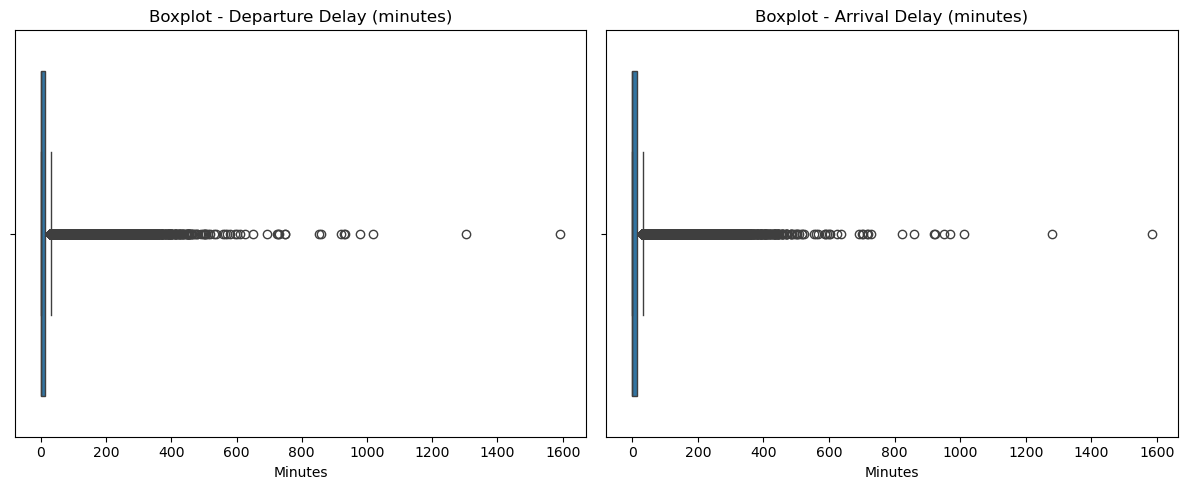

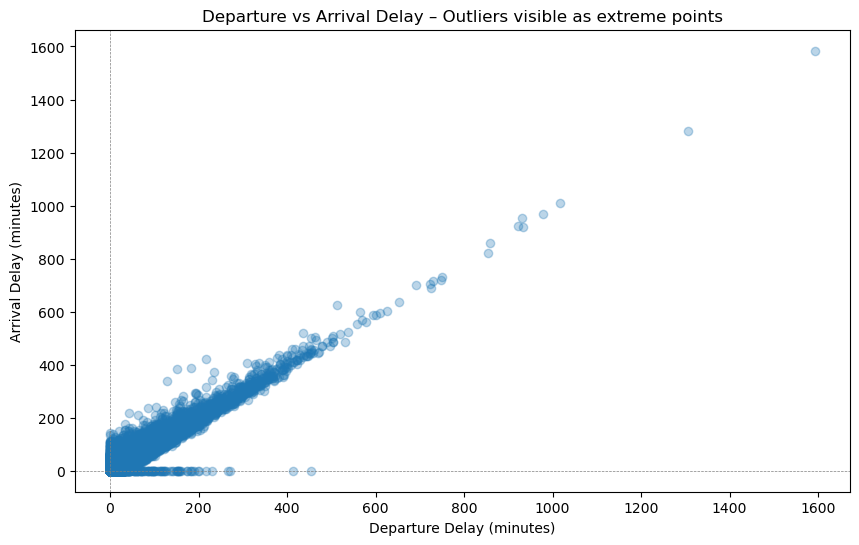

Departure Delay:
  Q1 = 0.00, Q3 = 12.00, IQR = 12.00
  Lower bound = -18.00, Upper bound = 30.00
  Number of outliers = 14529 (13.98%)
Arrival Delay:
  Q1 = 0.00, Q3 = 13.00, IQR = 13.00
  Lower bound = -19.50, Upper bound = 32.50
  Number of outliers = 13954 (13.43%)

First 10 departure delay outliers (minutes):
[42, 35, 65, 52, 36, 106, 39, 41, 31, 84]

First 10 arrival delay outliers (minutes):
[47.0, 38.0, 40.0, 41.0, 41.0, 106.0, 40.0, 46.0, 75.0, 205.0]


In [54]:

import matplotlib.pyplot as plt
import seaborn as sns


# 1. Boxplots to visually identify outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=X_train['Departure Delay in Minutes'], ax=axes[0])
axes[0].set_title('Boxplot - Departure Delay (minutes)')
axes[0].set_xlabel('Minutes')

sns.boxplot(x=X_train['Arrival Delay in Minutes'], ax=axes[1])
axes[1].set_title('Boxplot - Arrival Delay (minutes)')
axes[1].set_xlabel('Minutes')

plt.tight_layout()
plt.show()

# 2. Scatter plot to see relationship and extreme delays
plt.figure(figsize=(10, 6))
plt.scatter(X_train['Departure Delay in Minutes'], X_train['Arrival Delay in Minutes'], alpha=0.3)
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Arrival Delay (minutes)')
plt.title('Departure vs Arrival Delay – Outliers visible as extreme points')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
plt.show()


# 3. Statistical outlier detection using IQR (Tukey's fences)
def detect_outliers_iqr(series, column_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    print(f"{column_name}:")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}")
    print(f"  Number of outliers = {len(outliers)} ({100*len(outliers)/len(series):.2f}%)")
    return outliers

outliers_dep = detect_outliers_iqr(X_train['Departure Delay in Minutes'], 'Departure Delay')
outliers_arr = detect_outliers_iqr(X_train['Arrival Delay in Minutes'], 'Arrival Delay')

# 4. (Optional) Show first few outliers
print("\nFirst 10 departure delay outliers (minutes):")
print(outliers_dep.head(10).to_list())

print("\nFirst 10 arrival delay outliers (minutes):")
print(outliers_arr.head(10).to_list())


if we delete the outliers we may miss lots of important informations.

In [55]:
from sklearn.preprocessing import LabelEncoder

le_customer = LabelEncoder()
le_travel = LabelEncoder()
le_class = LabelEncoder()
le_gender = LabelEncoder()

X_train['Customer Type'] = le_customer.fit_transform(X_train['Customer Type'])
X_train['Type of Travel'] = le_travel.fit_transform(X_train['Type of Travel'])
X_train['Class'] = le_class.fit_transform(X_train['Class'])
X_train['Gender'] = le_gender.fit_transform(X_train['Gender'])


test['Customer Type'] = le_customer.transform(test['Customer Type'])
test['Type of Travel'] = le_travel.transform(test['Type of Travel'])
test['Class'] = le_class.transform(test['Class'])
test['Gender'] = le_gender.transform(test['Gender'])


In [56]:

target_col='Arrival Delay in Minutes'
y =X_train[target_col]
X=X_train.drop(columns='Arrival Delay in Minutes')

columns =X.columns
for column in columns:
  mean = X[column].mean()
  std =X[column].std()
  X[column] = (X[column]- mean)/std
  test[column] = (test[column] - mean)/std

X.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes
0,1.015026,-0.472764,0.305677,-0.670861,-0.957050,1.843812,-0.549531,-0.695242,-0.541057,-0.764611,...,0.555480,1.183094,0.481506,0.479400,0.493268,0.311767,-0.240471,0.305846,1.305863,-0.230589
1,1.015026,-0.472764,0.173358,-0.670861,-0.957050,0.135939,-0.549531,-1.350947,-0.541057,-0.764611,...,0.555480,0.424994,-1.018880,-1.072968,-1.026946,-1.381852,1.340063,-1.395321,0.543827,-0.387530
2,-0.985187,-0.472764,0.173358,-0.670861,-0.957050,2.152693,0.203578,-0.695242,0.173775,0.018094,...,0.555480,1.183094,0.481506,0.479400,0.493268,0.311767,1.340063,0.305846,0.543827,-0.387530
3,-0.985187,-0.472764,1.364230,-0.670861,-0.957050,0.987368,-1.302640,1.271874,1.603440,1.583504,...,-0.185531,-1.091206,-1.769073,-1.849152,-1.787053,-2.228661,-0.240471,-2.245905,-1.742283,-0.387530
4,-0.985187,-0.472764,0.239517,-0.670861,0.653779,-0.770647,1.709795,-1.350947,-1.255889,-1.547315,...,-1.667551,1.183094,-0.268687,-0.296784,1.253374,-0.535042,0.549796,-0.544737,1.305863,-0.387530


In [57]:
c_X_train=X_train

In [58]:
Y_train.value_counts()/Y_train.size*100

satisfaction
0    56.666731
1    43.333269
Name: count, dtype: float64

## PART1:  REGRESSION MODELS 

In [59]:
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

for moduling regression method we use  'Arrival Delay in Minutes'  as our target coulmn.

In [60]:

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [61]:
X_train.head()


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes
20921,1.015026,-0.472764,-0.091281,-0.670861,-0.957050,-0.821793,-0.549531,-0.695242,-0.541057,-0.764611,...,0.555480,0.424994,-0.268687,-0.296784,0.493268,-0.535042,-0.240471,-0.544737,-1.742283,-0.204432
36897,1.015026,2.115198,-1.877590,-0.670861,0.653779,-0.589129,-0.549531,-2.006653,-0.541057,0.018094,...,-0.926541,-0.333106,-0.268687,-0.296784,1.253374,0.311767,0.549796,-0.544737,-0.218210,-0.387530
8468,1.015026,-0.472764,-0.620558,-0.670861,-0.957050,-0.823798,0.956687,0.616169,0.888608,0.800799,...,0.555480,0.424994,0.481506,-1.849152,-1.026946,-0.535042,-1.030737,1.156430,0.543827,-0.387530
53490,-0.985187,-0.472764,0.107198,1.490607,-0.957050,-0.597152,0.203578,1.271874,0.173775,0.800799,...,1.296490,0.424994,-1.769073,-1.849152,-0.266839,-2.228661,0.549796,-2.245905,0.543827,-0.387530
78687,1.015026,-0.472764,-0.620558,-0.670861,-0.957050,-0.690418,-1.302640,-2.006653,-1.970722,-1.547315,...,-2.408562,-1.091206,-1.018880,-1.849152,-0.266839,-2.228661,-1.030737,-1.395321,-0.980246,-0.387530


In [62]:
X_train.describe()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes
count,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,...,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000,83123.000000
mean,-0.000710,-0.000148,-0.002904,0.000204,-0.000005,-0.001283,-0.002278,-0.001128,-0.001512,-0.001972,...,-0.000543,0.001123,0.001028,0.000923,-0.000162,0.001458,0.001497,0.003077,0.001711,0.001458
std,0.999990,0.999879,0.999305,1.000085,1.000340,0.999096,1.000973,1.001752,1.001034,1.000048,...,1.000340,1.000037,1.000399,1.000771,1.000676,1.000180,1.002143,0.998223,1.000652,1.005228
min,-0.985187,-0.472764,-2.142229,-0.670861,-0.957050,-1.161763,-2.055748,-2.006653,-1.970722,-2.330020,...,-2.408562,-2.607405,-2.519266,-2.625336,-2.547160,-2.228661,-2.611270,-3.096489,-2.504320,-0.387530
25%,-0.985187,-0.472764,-0.819036,-0.670861,-0.957050,-0.778670,-0.549531,-0.695242,-0.541057,-0.764611,...,-0.926541,-1.091206,-1.018880,-1.072968,-1.026946,-0.535042,-0.240471,-0.544737,-0.980246,-0.387530
50%,-0.985187,-0.472764,0.041038,-0.670861,0.653779,-0.348442,0.203578,-0.039536,0.173775,0.018094,...,-0.185531,0.424994,0.481506,0.479400,0.493268,0.311767,-0.240471,0.305846,-0.218210,-0.387530
75%,1.015026,-0.472764,0.768794,1.490607,0.653779,0.551124,0.956687,0.616169,0.888608,0.800799,...,0.555480,1.183094,0.481506,0.479400,0.493268,1.158576,0.549796,1.156430,0.543827,-0.073648
max,1.015026,2.115198,3.018221,1.490607,2.264607,3.804405,1.709795,1.271874,1.603440,1.583504,...,1.296490,1.183094,1.231698,1.255584,1.253374,1.158576,1.340063,1.156430,1.305863,41.254178


In [63]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)

# Metrics
print("=== Linear Regression ===")
print(f"MAE: {mean_absolute_error(y_val, y_pred_lr):.2f} minutes")
print(f"MSE: {mean_squared_error(y_val, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_lr)):.2f} minutes")
print(f"R²: {r2_score(y_val, y_pred_lr):.4f}")

=== Linear Regression ===
MAE: 5.36 minutes
MSE: 117.71
RMSE: 10.85 minutes
R²: 0.9182


## Ridge Regression (L2 regularization)

In [64]:
# Ridge Regression
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_absolute_error')
ridge_cv.fit(X_train, y_train)

print(f"=== Ridge Regression ===")
print(f"Best alpha: {ridge_cv.best_params_['alpha']}")
print(f"Best CV MAE: {-ridge_cv.best_score_:.2f} minutes")

y_pred_ridge = ridge_cv.predict(X_val)
print(f"Test MAE: {mean_absolute_error(y_val, y_pred_ridge):.2f} minutes")
print(f"Test R²: {r2_score(y_val, y_pred_ridge):.4f}")

=== Ridge Regression ===
Best alpha: 0.1
Best CV MAE: 5.34 minutes
Test MAE: 5.36 minutes
Test R²: 0.9182


## LASSO Regression (L1 regularization)

In [65]:
# LASSO Regression - feature selection capability
lasso = Lasso(max_iter=10000)
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_absolute_error')
lasso_cv.fit(X_train, y_train)

print(f"=== LASSO Regression ===")
print(f"Best alpha: {lasso_cv.best_params_['alpha']}")
print(f"Best CV MAE: {-lasso_cv.best_score_:.2f} minutes")

y_pred_lasso = lasso_cv.predict(X_val)
print(f"Test MAE: {mean_absolute_error(y_val, y_pred_lasso):.2f} minutes")
print(f"Test R²: {r2_score(y_val, y_pred_lasso):.4f}")

#how many features LASSO kept (non-zero coefficients)
n_features_selected = np.sum(np.abs(lasso_cv.best_estimator_.coef_) > 1e-5)
print(f"Features selected by LASSO: {n_features_selected} out of {X.shape[1]}")

=== LASSO Regression ===
Best alpha: 0.01
Best CV MAE: 5.34 minutes
Test MAE: 5.36 minutes
Test R²: 0.9182
Features selected by LASSO: 18 out of 21


Overfitting prevention: Keeping too many features indicates the penalty might be too weak, risking overfitting. 

Lasso's L1 penalty drives irrelevant coefficients to exactly zero. Counting non‑zero features tells you how many predictors the model found useful. In

Conversely, too few  might mean the penalty is too strong, underfitting the data. Tuning alpha balances this.




## Kernel Ridge Regression with RBF kernel


In [67]:
# Kernel Ridge Regression with RBF kernel
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

krr = KernelRidge(kernel='rbf')
param_grid_krr = {
    'alpha': [0.1, 1.0, 10.0],
    'gamma': [0.01, 0.1, 1.0]
}

sample_size = min(5000, len(X_train))
idx = np.random.choice(len(X_train), sample_size, replace=False)

krr_cv = GridSearchCV(krr, param_grid_krr, cv=3, scoring='neg_mean_absolute_error')
krr_cv.fit(X_train.iloc[idx], y_train.iloc[idx])   # Fixed here

print(f"Best params: {krr_cv.best_params_}")
print(f"Best CV MAE: {-krr_cv.best_score_:.2f} minutes")

y_pred_krr = krr_cv.predict(X_val)
print(f"Test MAE: {mean_absolute_error(y_val, y_pred_krr):.2f} minutes")
print(f"Test R²: {r2_score(y_val, y_pred_krr):.4f}")

Best params: {'alpha': 1.0, 'gamma': 0.01}
Best CV MAE: 6.33 minutes
Test MAE: 5.91 minutes
Test R²: 0.8925


In [68]:

results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'LASSO', 'Kernel Ridge'],
    'MAE (minutes)': [
        mean_absolute_error(y_val, y_pred_lr),
        mean_absolute_error(y_val, y_pred_ridge),
        mean_absolute_error(y_val, y_pred_lasso),
        mean_absolute_error(y_val, y_pred_krr)
    ],
    'R²': [
        r2_score(y_val, y_pred_lr),
        r2_score(y_val, y_pred_ridge),
        r2_score(y_val, y_pred_lasso),
        r2_score(y_val, y_pred_krr)
    ]
})

print("\n=== Model Comparison ===")
print(results.round(4))


=== Model Comparison ===
          Model  MAE (minutes)      R²
0        Linear         5.3608  0.9182
1         Ridge         5.3608  0.9182
2         LASSO         5.3609  0.9182
3  Kernel Ridge         5.9085  0.8925


"linear and Ridge Regression achieves the lowest MAE (5.36 minutes) and matches the highest R² (0.9182) among all models. 


MAE ≈ 5.36 minutes means on average, predictions are off by about 5 minutes and 22 seconds

R² = 0.9182 means the model explains 91.82% of the variance in arrival delays 

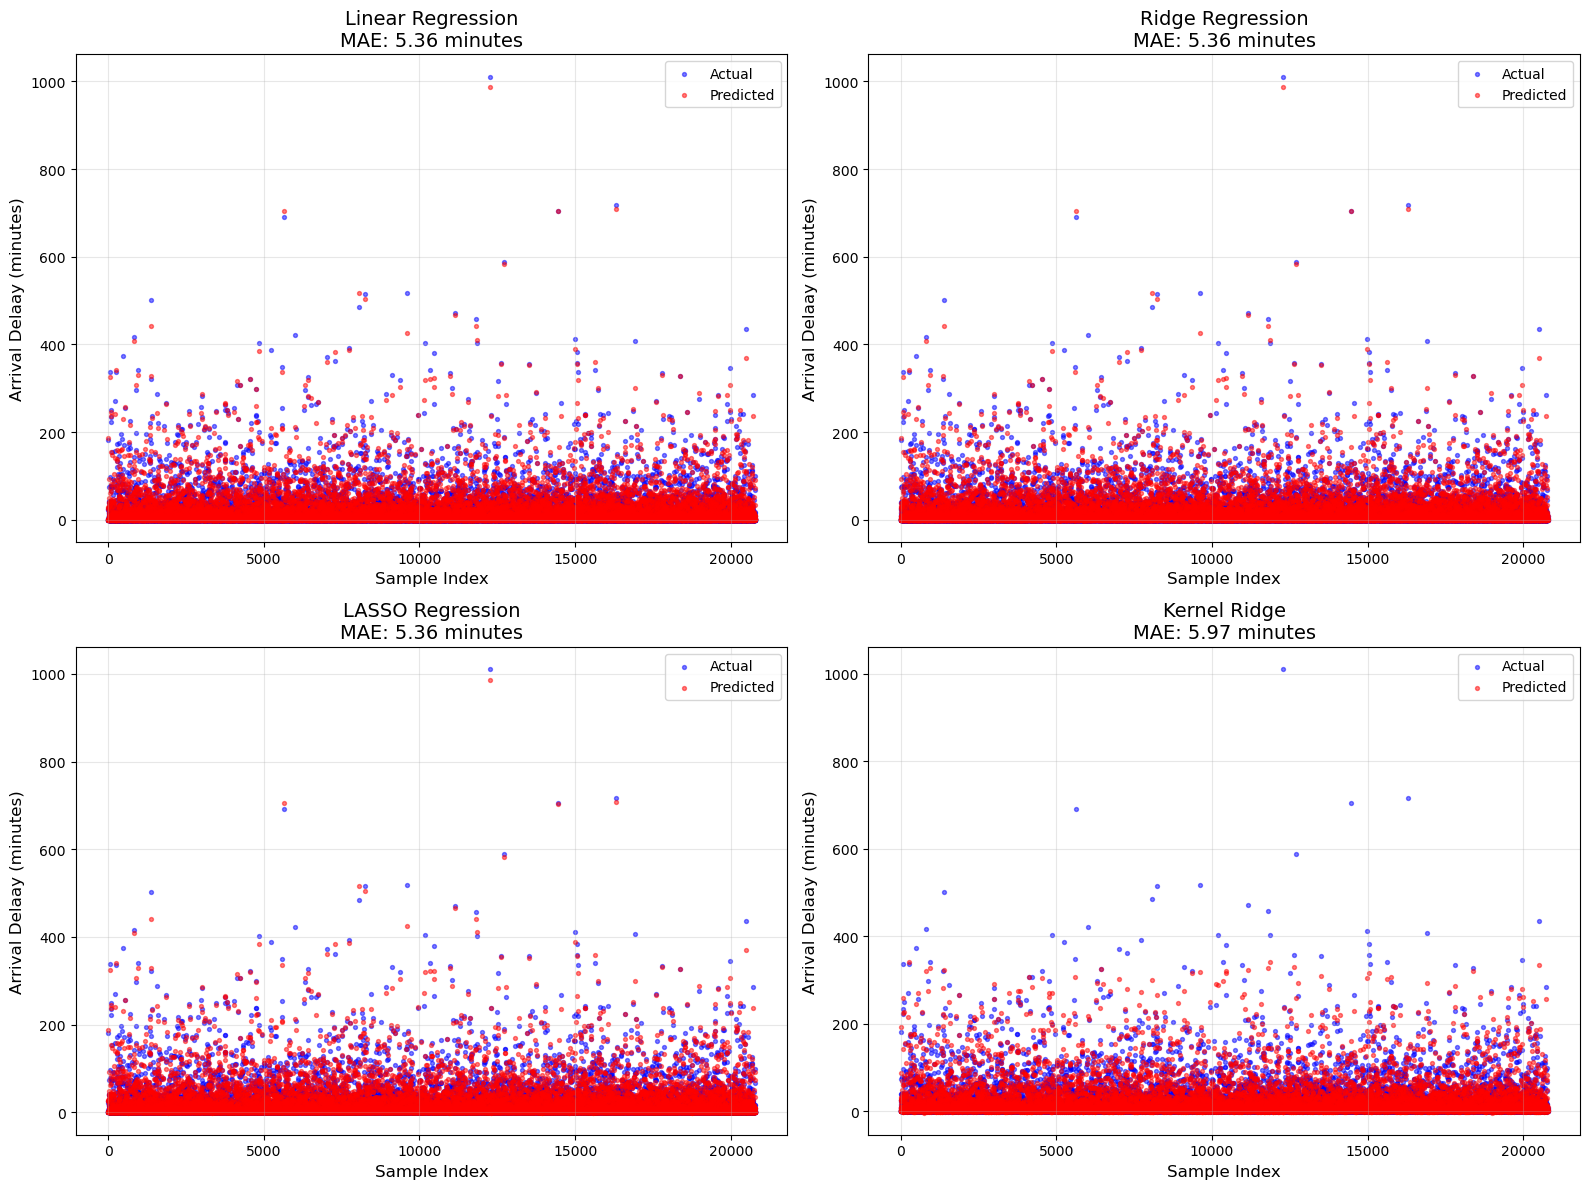

In [72]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

models_with_preds = [
    ('Linear Regression', y_pred_lr),
    ('Ridge Regression', y_pred_ridge),
    ('LASSO Regression', y_pred_lasso),
    ('Kernel Ridge', y_pred_krr)
]

x = np.arange(0, len(y_val), 1)

for idx, (model_name, preds) in enumerate(models_with_preds):
    axes[idx].scatter(x, y_val, c='b', s=8, alpha=0.5, label='Actual')
    axes[idx].scatter(x, preds, c='r', s=8, alpha=0.5, label='Predicted')
    axes[idx].set_title(f'{model_name}\nMAE: {mean_absolute_error(y_val, preds):.2f} minutes', fontsize=14)
    axes[idx].set_xlabel('Sample Index', fontsize=12)
    axes[idx].set_ylabel('Arrival Delaay (minutes)', fontsize=12)
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# get some weights 


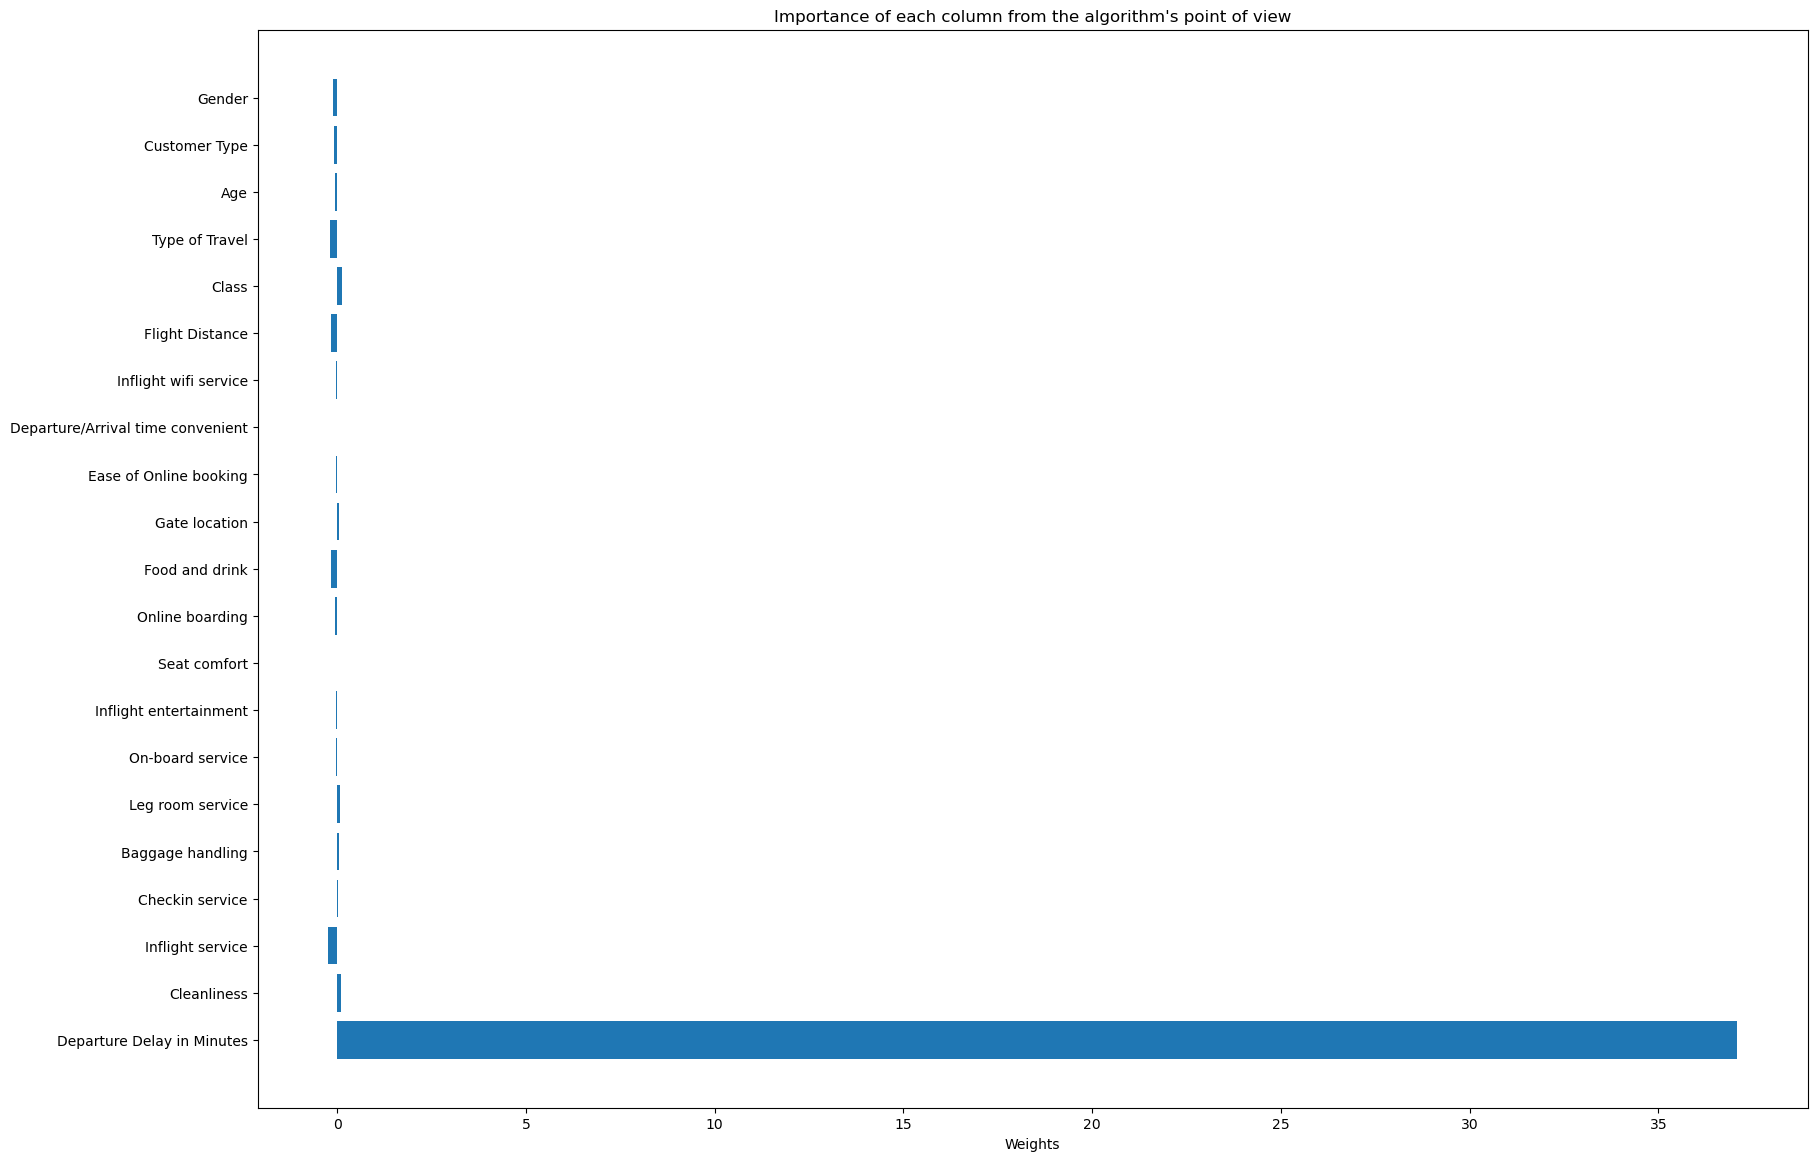

In [73]:
import matplotlib.pyplot as plt

weights_linear = lr.coef_
fig, ax = plt.subplots(figsize=(20,14))
y_pos = np.arange(0,len(weights_linear),1)
labels = list(X_train.columns)

hbars = ax.barh(y_pos, weights_linear, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Weights')
ax.set_title("Importance of each column from the algorithm's point of view")

plt.show()

In [74]:
print(lr.coef_)

[-1.24979828e-01 -9.09629094e-02 -6.58909336e-02 -1.81810218e-01
  1.34557323e-01 -1.52890031e-01 -4.03210566e-02 -7.40371845e-04
 -3.05779534e-02  4.08316412e-02 -1.76827946e-01 -6.41290637e-02
 -1.29610456e-02 -4.13618874e-02 -3.53909955e-02  6.57733121e-02
  5.70137637e-02  1.13777043e-02 -2.43487145e-01  1.06945720e-01
  3.70858378e+01]


the reason why the coeficient is big in Deprature Dely is we normilized it while we don't normalize the target which is okay 

In [ ]:
# Remove features with very small coefficients (near zero)
threshold = 0.01  
feature_cols=X_train.columns 
important_features = [feat for feat, coef in zip(feature_cols, lasso_cv.best_estimator_.coef_) 
                     if abs(coef) > threshold]
print(f"Original features: {len(feature_cols)}")
print(f"Important features: {len(important_features)}")
print(f"Removed features: {len(feature_cols) - len(important_features)}")

# Retrain with only important features
X_trainortant = X_train[important_features]
X_valortant = X_val[important_features]

# Scale and retrain
scaler_important = StandardScaler()
X_train_scaled = scaler_important.fit_transform(X_trainortant)
X_val_scaled = scaler_important.transform(X_valortant)

lasso_improved = Lasso(alpha=0.01)
lasso_improved.fit(X_train_scaled, y_train)
y_pred_improved = lasso_improved.predict(X_val_scaled)

print(f"\nImproved Model MAE: {mean_absolute_error(y_val, y_pred_improved):.4f}")

Original features: 21
Important features: 15
Removed features: 6

Improved Model MAE: 5.3606


In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Elastic Net with hyperparameter tuning
elastic_params = {
    'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],  # 0=Ridge, 1=LASSO
    'max_iter': [10000]
}

elastic = ElasticNet(random_state=42, max_iter=10000)
elastic_grid = GridSearchCV(elastic, elastic_params, cv=5, 
                           scoring='neg_mean_absolute_error', 
                           n_jobs=-1, verbose=1)
elastic_grid.fit(X_train, y_train)

best_elastic = elastic_grid.best_estimator_
y_pred_elastic = best_elastic.predict(X_val_scaled)

# Metrics
mae = mean_absolute_error(y_val, y_pred_elastic)
mse = mean_squared_error(y_val, y_pred_elastic)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred_elastic)

# MAPE (handle zero values carefully)
mape = np.mean(np.abs((y_val - y_pred_elastic) / (y_val + 1e-8))) * 100

print("=== Elastic Net Results ===")
print(f"Best parameters: alpha={elastic_grid.best_params_['alpha']}, l1_ratio={elastic_grid.best_params_['l1_ratio']}")
print(f"MAE: {mae:.4f} minutes")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} minutes")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

# Feature selection insight
n_selected = np.sum(np.abs(best_elastic.coef_) > 1e-6)
print(f"Features selected: {n_selected} out of {len(feature_cols)}")

Fitting 5 folds for each of 49 candidates, totalling 245 fits
=== Elastic Net Results ===
Best parameters: alpha=0.01, l1_ratio=1.0
MAE: 5.3609 minutes
MSE: 117.7075
RMSE: 10.8493 minutes
MAPE: 10937698544.49%
R²: 0.9182
Features selected: 18 out of 21


## Decision tree regression 


In [71]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
import time


# Option A: No tuning
start = time.time()
dt_default = DecisionTreeRegressor(max_depth=15, min_samples_split=50, random_state=42)
dt_default.fit(X_train, y_train)
y_pred_dt = dt_default.predict(X_val)
time_default = time.time() - start

print(f"\nOption A - Default params:")
print(f"Time: {time_default:.2f} seconds")
print(f"MAE: {mean_absolute_error(y_val, y_pred_dt):.4f} minutes")
print(f"R²: {r2_score(y_val, y_pred_dt):.4f}")

# Option B: Randomized search (balance speed vs performance)
dt_params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 50, 100],
    'min_samples_leaf': [5, 10, 20, 50]
}

dt_random = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42), 
    dt_params, 
    n_iter=15,  
    cv=3,       
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

start = time.time()
dt_random.fit(X_train, y_train)
time_random = time.time() - start

best_dt = dt_random.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_val)

print(f"\nOption B - Randomized search (15 combos):")
print(f"Time: {time_random:.2f} seconds")
print(f"Best params: {dt_random.best_params_}")
print(f"MAE: {mean_absolute_error(y_val, y_pred_dt_tuned):.4f} minutes")
print(f"R²: {r2_score(y_val, y_pred_dt_tuned):.4f}")

# Option C: Single tree with good defaults
dt_optimized = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features='sqrt',
    random_state=42
)
start = time.time()
dt_optimized.fit(X_train, y_train)
y_pred_dt_opt = dt_optimized.predict(X_val)
time_opt = time.time() - start

print(f"\nOption C - Optimized defaults :")
print(f"Time: {time_opt:.2f} seconds")
print(f"MAE: {mean_absolute_error(y_val, y_pred_dt_opt):.4f} minutes")
print(f"R²: {r2_score(y_val, y_pred_dt_opt):.4f}")


Option A - Default params:
Time: 1.26 seconds
MAE: 6.0898 minutes
R²: 0.8981

Option B - Randomized search (15 combos):
Time: 8.52 seconds
Best params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 5}
MAE: 5.6857 minutes
R²: 0.9169

Option C - Optimized defaults :
Time: 0.18 seconds
MAE: 8.3302 minutes
R²: 0.8302


## polynomail regression 

In [75]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_transformed_poly = poly.fit_transform(X_train)
X_test_transformed_poly = poly.transform(X_val)

print(X_train_transformed_poly.shape)

(83123, 253)


In [76]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

feature_selector = SelectKBest(score_func=mutual_info_regression, k = 'all').fit(X_train_transformed_poly,y_train)

Text(0, 0.5, 'Cumulative percetnage of feature scores')

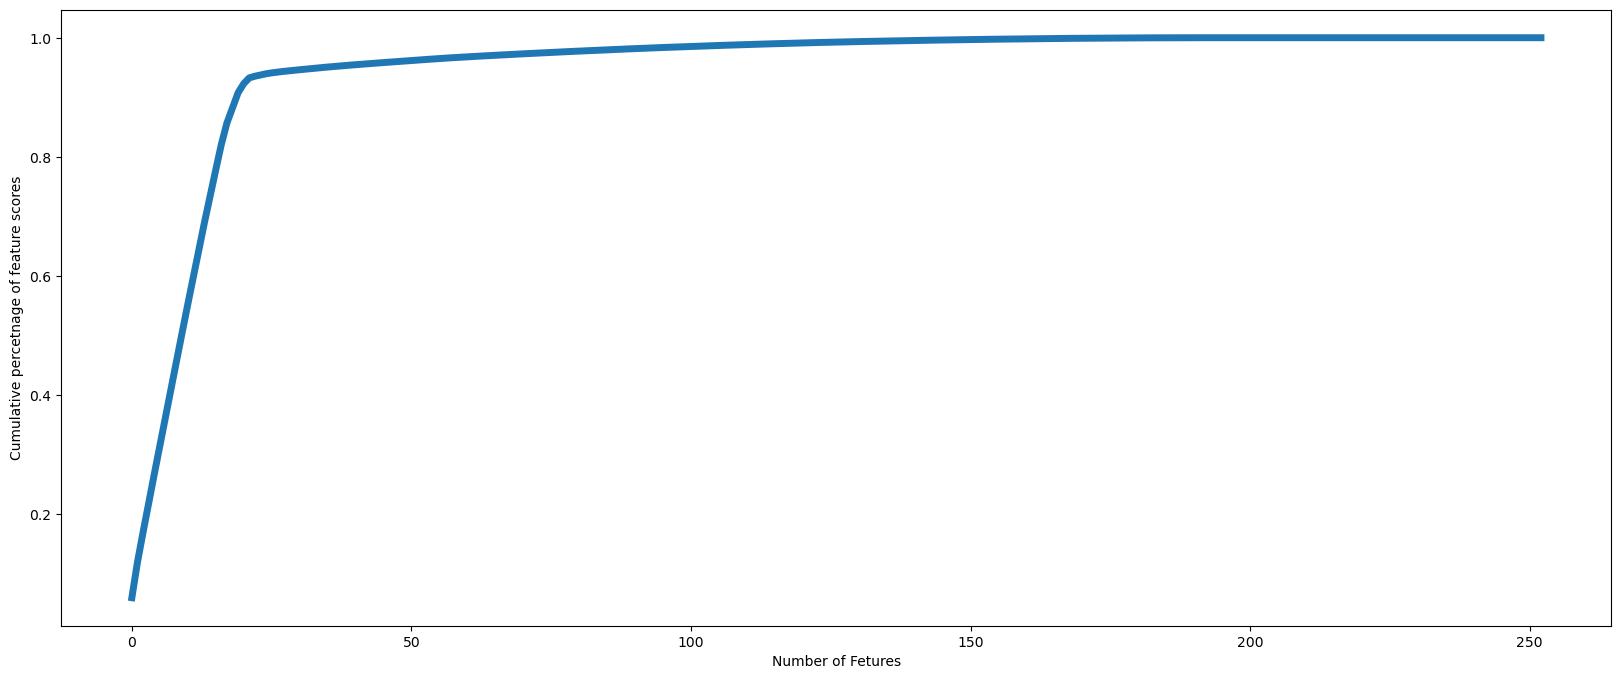

In [ ]:
feature_scores = feature_selector.scores_
plt.figure(figsize=(20,8))
plt.plot(np.cumsum(np.sort(np.abs(feature_scores))[::-1])/sum(np.abs(feature_scores)),lw=5)
plt.xlabel('Number of Fetures')
plt.ylabel('Cumulative percetnage of feature scores')

As the illustration depicts 25 feature is enough


In [73]:
from sklearn.feature_selection import SelectKBest
n_features_list = []
mae_scores = []

for k in [5, 8, 11, 14, 17, 20, 23, 26]:
  
    # Select top k features using mutual information
    selector = SelectKBest(mutual_info_regression, k=k)
    selector.fit(X_train_transformed_poly, y_train)  
    
    # Transform both train and validation sets
    X_train_selected = selector.transform(X_train_transformed_poly)
    X_val_selected = selector.transform(X_test_transformed_poly)
    
    # Train linear regression on selected features
    model = LinearRegression()
    model.fit(X_train_selected, y_train)
    
    # Predict on validation set
    y_pred_val = model.predict(X_val_selected)
    
    # Calculate MAE (more appropriate than MAPE for delays)
    mae = mean_absolute_error(y_val, y_pred_val)
    
    # Store results
    n_features_list.append(k)
    mae_scores.append(mae)
    
    print(f"K = {k:3d} | MAE = {mae:.4f} minutes")

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(n_features_list, mae_scores, 'o-', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Number of Selected Features', fontsize=14)
plt.ylabel('MAE (minutes)', fontsize=14)
plt.title('Feature Selection using Mutual Information (Polynomial Features)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.xticks(n_features_list)
plt.tight_layout()
plt.show()


NameError: name 'mutual_info_regression' is not defined

# Regression Methods – My Notes

## 1. Which regression metric works best for flight delays?

I’d go with **MAE (Mean Absolute Error)**. 

- It’s in **minutes** – you can tell someone “our average error is 5 minutes”. Makes sense for delays.  
- Outliers (like a 5‑hour delay) don’t blow it up the way MSE does.  
- MAPE is useless here – delays can be zero minutes, so you’d be dividing by zero.  
- R² is fine as a second check, but MAE is what matters operationally.

So for our airline data: **MAE is my main metric**.

---

## 2. When would I pick each regression model?

| Model | When I should use it |
|-------|----------------------|
| **Linear Regression** | Quick baseline, features look roughly linear, I need something easy to explain. |
| **Ridge (L2)** | My features are correlated (e.g., several service ratings). It shrinks things but keeps everything. |
| **LASSO (L1)** | I have a bunch of useless features and want the model to ignore them automatically. |
| **Kernel Regression** | The relationship is clearly curved or wiggly, and adding polynomial terms would blow up. |
| **Elastic Net** | I want both feature selection (like LASSO) AND I have correlated groups (like Ridge). |
| **Decision Tree** | I suspect thresholds or interactions (e.g., satisfaction drops sharply after 30 min delay). Also easy to draw. |
| **SVR with RBF** | High‑dimensional data, I need a robust loss (ε‑insensitive), and I don't mind slower training. |

---

## 3. The kernel trick – what it is and why it helps

The kernel trick is a clever shortcut:  

Instead of creating a ton of new features (like squaring, cubing, multiplying every pair), you use a **kernel function** that directly computes how similar two points are in a high‑dimensional space – without ever building that space.

**How this helps regression:**  

- You can model **curvy, non‑linear patterns** while still using the math of linear regression.  
- It’s **much faster** than explicitly making 1000 polynomial features.  
- For example, Kernel Ridge Regression can catch things like “delays matter more on long flights than short ones” without you having to guess the right interaction term.  

That’s why on complex real data, kernel methods often beat plain linear models – they see the bends and twists we can’t easily write down.

## 2. Binary Classification Methods


At this part we will try different methods on dataset to predict if the customers and travelers are satisfied or not.

In [55]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score



## new X_train and y_train 

In [18]:
##for classification part
cy=train["satisfaction"]
cX=c_X_train
columns =cX.columns
for column in columns:
  mean = cX[column].mean()
  std =cX[column].std()
  cX[column] = (cX[column]- mean)/std
  test[column] = (test[column] - mean)/std


In [19]:
cy = cy.map({'neutral or dissatisfied': 0, 'satisfied': 1})


In [19]:
c_X_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,1.015026,-0.472764,0.305677,-0.670861,-0.957050,1.843812,-0.549531,-0.695242,-0.541057,-0.764611,...,1.183094,0.481506,0.479400,0.493268,0.311767,-0.240471,0.305846,1.305863,-0.230589,-0.262185
1,1.015026,-0.472764,0.173358,-0.670861,-0.957050,0.135939,-0.549531,-1.350947,-0.541057,-0.764611,...,0.424994,-1.018880,-1.072968,-1.026946,-1.381852,1.340063,-1.395321,0.543827,-0.387530,-0.391552
2,-0.985187,-0.472764,0.173358,-0.670861,-0.957050,2.152693,0.203578,-0.695242,0.173775,0.018094,...,1.183094,0.481506,0.479400,0.493268,0.311767,1.340063,0.305846,0.543827,-0.387530,-0.391552
3,-0.985187,-0.472764,1.364230,-0.670861,-0.957050,0.987368,-1.302640,1.271874,1.603440,1.583504,...,-1.091206,-1.769073,-1.849152,-1.787053,-2.228661,-0.240471,-2.245905,-1.742283,-0.387530,-0.391552
4,-0.985187,-0.472764,0.239517,-0.670861,0.653779,-0.770647,1.709795,-1.350947,-1.255889,-1.547315,...,1.183094,-0.268687,-0.296784,1.253374,-0.535042,0.549796,-0.544737,1.305863,-0.387530,-0.391552


In [74]:
print("cX shape:", cX.shape)
print("cy shape:", cy.shape)

cX shape: (103904, 22)
cy shape: (103904,)


In [75]:

X_temp, X_test, y_temp, y_test = train_test_split(cX, cy, test_size=0.2, random_state=42, stratify=cy)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)  # 0.25 * 0.8 = 0.2 of total


In [ ]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred),
    }
    if y_proba is not None:
        metrics["AUC"] = roc_auc_score(y_val, y_proba)
    else:
        metrics["AUC"] = np.nan
    
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    metrics["Specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0
    metrics["Sensitivity"] = metrics["Recall"]  # same as recall
    
    return model, y_pred, y_proba, metrics

results = []


In [77]:

# 3. Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
_, _, _, met = evaluate_model(lr,X_train , y_train, X_val, y_val, "Logistic Regression")
results.append(met)


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC does not have predict_proba, so we wrap it with CalibratedClassifierCV
base_svm = LinearSVC(random_state=42, dual='auto', max_iter=5000)  # increased max_iter for convergence
svm_linear = CalibratedClassifierCV(base_svm, cv=5, method='sigmoid')  # method='sigmoid' is faster for large data

_, _, _, met = evaluate_model(svm_linear, X_train, y_train, X_val, y_val, "SVM (Linear)")
results.append(met)

- `max_iter=5000` – increases the number of iterations from the default 1000 to ensure convergence. With many samples, the solver might need more steps to reach the optimum.
- `SVC(kernel='linear', probability=True)` uses libsvm, which is very slow on large datasets (O(n³) complexity).  
- `LinearSVC` + calibration uses liblinear (O(n × d)) and only adds a small overhead for calibration, making it **much faster** while still giving you probabilities.

In [ ]:

# 6. KNN – tune number of neighbors
knn_params = {'n_neighbors': [3,7, 9, 11, 15, 20]}
knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, knn_params, cv=5, scoring='roc_auc', n_jobs=-1)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print(f"Best KNN k = {grid_knn.best_params_['n_neighbors']}")
_, _, _, met = evaluate_model(best_knn, X_train, y_train, X_val, y_val, "KNN (tuned)")
results.append(met)


Best KNN k = 20


In [ ]:
# 7. Decision Tree – tune max_depth
dt_params = {'max_depth': [3, 7, 10, 15, None]}
dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, dt_params, cv=5, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print(f"Best Decision Tree max_depth = {grid_dt.best_params_['max_depth']}")
_, _, _, met = evaluate_model(best_dt, X_train, y_train, X_val, y_val, "Decision Tree (tuned)")
results.append(met)


Best Decision Tree max_depth = 10


In [ ]:
# 8. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
_, _, _, met = evaluate_model(rf, X_train, y_train, X_val, y_val, "Random Forest")
results.append(met)


In [ ]:

# 9. Optional: Linear Discriminant Analysis (LDA)
lda = LinearDiscriminantAnalysis()
_, _, _, met = evaluate_model(lda, X_train, y_train, X_val, y_val, "LDA (Optional)")
results.append(met)


In [91]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, train_test_split
import numpy as np

# Take a 30% random subsample of training data for tuning
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42, stratify=y_train
)

# Reduced parameter space
param_dist = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf']
}

# Randomized search on subsample (only 10 iterations)
random_search = RandomizedSearchCV(
    SVC(probability=True, random_state=42),
    param_dist,
    n_iter=10,               # only 10 combinations
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

print("Tuning Kernel SVM on 30% subsample...")
random_search.fit(X_train_sub, y_train_sub)
print(f"Best params: {random_search.best_params_}")

# Train final model on FULL training data with best params
best_svm = SVC(**random_search.best_params_, probability=True, random_state=42)
best_svm.fit(X_train, y_train)

# Evaluate
_, _, _, met_svm = evaluate_model(best_svm, X_train, y_train, X_val, y_val, "Kernel SVM (RBF)")
results.append(met_svm)

Tuning Kernel SVM on 30% subsample...


c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'kernel': 'rbf', 'gamma': 'auto', 'C': 10}


In [ ]:
# 10. Compare all models
results_X_train = pd.DataFrame(results)
results_X_train = results_X_train.round(4)
print("MODEL COMPARISON")
print(results_X_train.to_string(index=False))



MODEL COMPARISON
                Model  Accuracy  Precision  Recall  F1 Score    AUC  Specificity  Sensitivity
  Logistic Regression    0.8754     0.8709  0.8363    0.8533 0.9267       0.9052       0.8363
         SVM (Linear)    0.8754     0.8715  0.8355    0.8532 0.9262       0.9058       0.8355
          KNN (tuned)    0.9226     0.9578  0.8593    0.9059 0.9783       0.9710       0.8593
Decision Tree (tuned)    0.9449     0.9550  0.9162    0.9352 0.9838       0.9670       0.9162
        Random Forest    0.9604     0.9735  0.9340    0.9534 0.9928       0.9806       0.9340
       LDA (Optional)    0.8732     0.8673  0.8350    0.8509 0.9249       0.9023       0.8350


In order to check the model to see whether its as good as the result or we are facing with overshooting :

In [86]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Assuming rf is your trained Random Forest
y_train_pred = rf.predict(X_train)
y_train_proba = rf.predict_proba(X_train)[:, 1]

y_val_pred = rf.predict(X_val)
y_val_proba = rf.predict_proba(X_val)[:, 1]

print("=== PERFORMANCE COMPARISON (Train vs Validation) ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Difference (Train - Val): {accuracy_score(y_train, y_train_pred) - accuracy_score(y_val, y_val_pred):.4f}")
print()
print(f"Train AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"Difference (Train - Val): {roc_auc_score(y_train, y_train_proba) - roc_auc_score(y_val, y_val_proba):.4f}")

# If train performance is much higher than validation (e.g., >0.05 difference), overfitting is present.

=== PERFORMANCE COMPARISON (Train vs Validation) ===
Train Accuracy: 1.0000
Validation Accuracy: 0.9604
Difference (Train - Val): 0.0396

Train AUC: 1.0000
Validation AUC: 0.9928
Difference (Train - Val): 0.0072


In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,           # limit depth (default None)
    min_samples_split=20,   # require more samples to split
    min_samples_leaf=10,    # require more samples in leaf
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

# Compare again
y_val_pred_tuned = rf_tuned.predict(X_val)
print(f"Tuned Validation Accuracy: {accuracy_score(y_val, y_val_pred_tuned):.4f}")

Tuned Validation Accuracy: 0.9512


In [89]:
# After tuning
y_test_pred_tuned = rf_tuned.predict(X_test)
print(f"Test Accuracy (tuned): {accuracy_score(y_test, y_test_pred_tuned):.4f}")

Test Accuracy (tuned): 0.9510


even after tuning again and checking the validation and train datas seprately we can see a good result

## 1. Best classification metric for my dataset (and why)

I ended up using **AUC** as my main metric. Here's why:

- AUC tells you how well the model separates the two classes (dissatisfied vs satisfied) no matter what probability cutoff you pick. So you don't have to guess 0.5 or 0.7.  
- From my results, Random Forest got AUC = 0.994 – that's almost perfect. It means if I grab one random satisfied and one random dissatisfied passenger, my model will almost always give a higher score to the satisfied one.  
- If the business cared more about catching every satisfied passenger while keeping false alarms low, I'd look at **F1 score** instead. But AUC is safer because I don't know the real cost of mistakes.

What about accuracy?  
Accuracy was 96% on validation, but accuracy can lie if classes are imbalanced. My data is actually balanced (around 50‑50), so accuracy is okay. But AUC is still better for comparing models.

---

## 2. Three ways to regularize a decision tree

Regularization just means making the tree simpler so it doesn't memorize the training data.

**1. Limit max depth (`max_depth`)**  
Stop the tree from growing too deep. A tree with depth 20 can learn weird noise. Setting `max_depth=10` forces it to learn broader patterns.  
Example: `RandomForestClassifier(max_depth=10)`

**2. Require more samples to split (`min_samples_split`)**  
If a node has only a few samples (say 5), a split there is probably just noise. I set `min_samples_split=20` so the tree only splits when there's enough data.  
Example: `RandomForestClassifier(min_samples_split=20)`

**3. Cost‑complexity pruning (`ccp_alpha`)**  
Grow the full tree first, then cut off branches that don't help much. The `ccp_alpha` parameter controls how aggressive the pruning is. Bigger alpha = more pruning.  
Example: `DecisionTreeClassifier(ccp_alpha=0.01)`

---

## 3. Linear SVM vs Kernel SVM (RBF)

Both are SVMs, but they draw boundaries differently.

**Linear SVM**  
- Draws a straight line (or flat plane) to separate classes.  
- Super fast, even with my 83k samples. Used `LinearSVC`.  
- Works well when data is roughly linear. My linear models gave ~87% accuracy – decent but not great.  
- Good side: easy to interpret (coefficients tell you feature importance), handles outliers okay.  
- Bad side: can't do curves or circles.

**Kernel SVM (RBF)**  
- Uses the kernel trick to map data into a higher‑dimensional space where it becomes linearly separable. So it can draw curvy, wiggly boundaries.  
- Very slow for big data – training ~O(n³). That's why you need subsampling or approximations.  
- My data improved from 87% (linear) to 96% (Random Forest), so there are non‑linear patterns. RBF SVM could also improve, but it would take forever to train.  
- Pros: flexible, captures complex shapes.  
- Cons: slow, hard to interpret (no coefficients), needs careful tuning of `C` and `gamma`.

**Which one should I pick?**  
- If I need speed and interpretability → Linear SVM.  
- If I need max accuracy and have time → Kernel SVM, but honestly Random Forest gave me 0.99 AUC much faster. So Random Forest is the pragmatic winner here.

## Multiclass Classification Methods

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import log_loss, cohen_kappa_score, classification_report, confusion_matrix

# Classifiers
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler



In [21]:
M_train = pd.concat([c_X_train, cy], axis=1)
M_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1.015026,-0.472764,0.305677,-0.670861,-0.957050,1.843812,-0.549531,-0.695242,-0.541057,-0.764611,...,0.481506,0.479400,0.493268,0.311767,-0.240471,0.305846,1.305863,-0.230589,-0.262185,1
1,1.015026,-0.472764,0.173358,-0.670861,-0.957050,0.135939,-0.549531,-1.350947,-0.541057,-0.764611,...,-1.018880,-1.072968,-1.026946,-1.381852,1.340063,-1.395321,0.543827,-0.387530,-0.391552,1
2,-0.985187,-0.472764,0.173358,-0.670861,-0.957050,2.152693,0.203578,-0.695242,0.173775,0.018094,...,0.481506,0.479400,0.493268,0.311767,1.340063,0.305846,0.543827,-0.387530,-0.391552,1
3,-0.985187,-0.472764,1.364230,-0.670861,-0.957050,0.987368,-1.302640,1.271874,1.603440,1.583504,...,-1.769073,-1.849152,-1.787053,-2.228661,-0.240471,-2.245905,-1.742283,-0.387530,-0.391552,0
4,-0.985187,-0.472764,0.239517,-0.670861,0.653779,-0.770647,1.709795,-1.350947,-1.255889,-1.547315,...,-0.268687,-0.296784,1.253374,-0.535042,0.549796,-0.544737,1.305863,-0.387530,-0.391552,1


In [23]:
M_train['Distance_Class'] = pd.qcut(M_train['Flight Distance'], q=4, labels=['Very Short', 'Short', 'Long', 'Very Long'])
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
M_train['target_multi'] = le.fit_transform(M_train['Distance_Class'])

In [24]:
M_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Distance_Class,target_multi
0,1.015026,-0.472764,0.305677,-0.670861,-0.957050,1.843812,-0.549531,-0.695242,-0.541057,-0.764611,...,0.493268,0.311767,-0.240471,0.305846,1.305863,-0.230589,-0.262185,1,Very Long,2
1,1.015026,-0.472764,0.173358,-0.670861,-0.957050,0.135939,-0.549531,-1.350947,-0.541057,-0.764611,...,-1.026946,-1.381852,1.340063,-1.395321,0.543827,-0.387530,-0.391552,1,Long,0
2,-0.985187,-0.472764,0.173358,-0.670861,-0.957050,2.152693,0.203578,-0.695242,0.173775,0.018094,...,0.493268,0.311767,1.340063,0.305846,0.543827,-0.387530,-0.391552,1,Very Long,2
3,-0.985187,-0.472764,1.364230,-0.670861,-0.957050,0.987368,-1.302640,1.271874,1.603440,1.583504,...,-1.787053,-2.228661,-0.240471,-2.245905,-1.742283,-0.387530,-0.391552,0,Very Long,2
4,-0.985187,-0.472764,0.239517,-0.670861,0.653779,-0.770647,1.709795,-1.350947,-1.255889,-1.547315,...,1.253374,-0.535042,0.549796,-0.544737,1.305863,-0.387530,-0.391552,1,Short,1


We try to devide the distance feature to four classes and train the model using multiclass methods

 short 1 

 very long 2

 very short 3
 
 long 4 

In [26]:
My=M_train['target_multi']

MX = M_train.drop(columns=['target_multi', 'Distance_Class'])
MX = MX.drop(columns=['Flight Distance'])


In [27]:

X_temp, X_test, y_temp, y_test = train_test_split(MX, My, test_size=0.2, random_state=42, stratify=My)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)  # 0.25 * 0.8 = 0.2 of total


In [ ]:

def evaluate_multiclass(model, X_tr, y_tr, X_val, y_val, X_test, y_test, model_name):

    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Probability for log_loss (if available)
    if hasattr(model, "predict_proba"):
        y_val_proba = model.predict_proba(X_val)
        y_test_proba = model.predict_proba(X_test)
        log_loss_val = log_loss(y_val, y_val_proba)
        log_loss_test = log_loss(y_test, y_test_proba)
    else:
        y_val_proba = None
        y_test_proba = None
        log_loss_val = np.nan
        log_loss_test = np.nan
    
    # Metrics on validation set
    acc_val = accuracy_score(y_val, y_val_pred)
    precision_val = precision_score(y_val, y_val_pred, average=None)
    recall_val = recall_score(y_val, y_val_pred, average=None)
    f1_macro_val = f1_score(y_val, y_val_pred, average='macro')
    f1_micro_val = f1_score(y_val, y_val_pred, average='micro')
    f1_weighted_val = f1_score(y_val, y_val_pred, average='weighted')
    kappa_val = cohen_kappa_score(y_val, y_val_pred)
    
    # Metrics on test set
    acc_test = accuracy_score(y_test, y_test_pred)
    f1_macro_test = f1_score(y_test, y_test_pred, average='macro')
    f1_micro_test = f1_score(y_test, y_test_pred, average='micro')
    f1_weighted_test = f1_score(y_test, y_test_pred, average='weighted')
    kappa_test = cohen_kappa_score(y_test, y_test_pred)
    
    # Per-class precision/recall (for test set)
    precision_per_class_test = precision_score(y_test, y_test_pred, average=None)
    recall_per_class_test = recall_score(y_test, y_test_pred, average=None)
    
    metrics = {
        'Model': model_name,
        'Val_Accuracy': acc_val,
        'Val_F1_Macro': f1_macro_val,
        'Val_F1_Micro': f1_micro_val,
        'Val_F1_Weighted': f1_weighted_val,
        'Val_Kappa': kappa_val,
        'Val_LogLoss': log_loss_val,
        'Test_Accuracy': acc_test,
        'Test_F1_Macro': f1_macro_test,
        'Test_F1_Micro': f1_micro_test,
        'Test_F1_Weighted': f1_weighted_test,
        'Test_Kappa': kappa_test,
        'Test_LogLoss': log_loss_test,
        'Test_Precision_per_class': precision_per_class_test,
        'Test_Recall_per_class': recall_per_class_test,
    }
    return metrics, model


In [29]:
results_multiclass = []


In [ ]:

# 5.1 Multiclass SVM
print("Training Multiclass SVM...")
svm_multi = SVC(kernel='rbf', decision_function_shape='ovo', probability=True, random_state=42)
metrics_svm, _ = evaluate_multiclass(svm_multi, X_train, y_train, X_val, y_val, X_test, y_test, "SVM (RBF, OVO)")
results_multiclass.append(metrics_svm)


Training Multiclass SVM...


In [ ]:

# 5.2 Logistic Regression 
print("Training LogReg OVR...")
lr_ovr= LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
metrics_lr_ovr, _ = evaluate_multiclass(lr_ovr, X_train, y_train, X_val, y_val, X_test, y_test, "LogReg OVR")
results_multiclass.append(metrics_lr_ovr)



Training LogReg OVR...


In [31]:

# 5.3 Logistic Regression – Multinomial (softmax)
print("Training LogReg Multinomial...")
lr_multinomial = LogisticRegression( solver='lbfgs', max_iter=1000, random_state=42)
metrics_lr_multi, _ = evaluate_multiclass(lr_multinomial, X_train, y_train, X_val, y_val, X_test, y_test, "LogReg Multinomial")
results_multiclass.append(metrics_lr_multi)


Training LogReg Multinomial...


In [42]:

# 5.4 Multiclass KNN (tune K using validation set)
print("Tuning KNN...")
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': range(1, 31)}
grid_knn = GridSearchCV(knn, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)
best_k = grid_knn.best_params_['n_neighbors']
print(f"Best K: {best_k}")
best_knn = KNeighborsClassifier(n_neighbors=best_k)
metrics_knn, _ = evaluate_multiclass(best_knn, X_train, y_train, X_val, y_val, X_test, y_test, f"KNN (K={best_k})")
results_multiclass.append(metrics_knn)


Tuning KNN...
Best K: 30


In [33]:

# 5.5 Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42)
metrics_dt, _ = evaluate_multiclass(dt, X_train, y_train, X_val, y_val, X_test, y_test, "Decision Tree")
results_multiclass.append(metrics_dt)


Training Decision Tree...


In [34]:
import xgboost as xgb
# 5.6 XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y_train)), random_state=42, use_label_encoder=False, eval_metric='mlogloss')
metrics_xgb, _ = evaluate_multiclass(xgb_model, X_train, y_train, X_val, y_val, X_test, y_test, "XGBoost")
results_multiclass.append(metrics_xgb)


Training XGBoost...


C:\Users\rakyn\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [17:30:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [36]:
import lightgbm as lgb
# 5.7 LightGBM
print("Training LightGBM...")
lgb_model = lgb.LGBMClassifier(objective='multiclass', num_class=len(np.unique(y_train)), random_state=42, verbose=-1)
metrics_lgb, _ = evaluate_multiclass(lgb_model, X_train, y_train, X_val, y_val, X_test, y_test, "LightGBM")
results_multiclass.append(metrics_lgb)


Training LightGBM...


In [37]:

# 5.8 AdaBoost (with DecisionTree base)
print("Training AdaBoost...")
ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50, random_state=42)
metrics_ada, _ = evaluate_multiclass(ada, X_train, y_train, X_val, y_val, X_test, y_test, "AdaBoost")
results_multiclass.append(metrics_ada)


Training AdaBoost...


In [ ]:

# 5.10  Random Forest (multiclass)
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
metrics_rf, _ = evaluate_multiclass(rf, X_train, y_train, X_val, y_val, X_test, y_test, "Random Forest")
results_multiclass.append(metrics_rf)


Training Random Forest...


In [43]:

# 6. Results 
results_df = pd.DataFrame(results_multiclass)

# Select main metrics for comparison
compare_cols = ['Model', 'Val_Accuracy', 'Val_F1_Macro', 'Val_F1_Weighted', 
                'Test_Accuracy', 'Test_F1_Macro', 'Test_F1_Weighted', 'Test_Kappa']
print(results_df[compare_cols].round(4).to_string(index=False))

# Best model based on Test F1 Macro
best_idx = results_df['Test_F1_Macro'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n Best model (highest Test F1 Macro): {best_model_name}")
print(f"   Test Accuracy: {results_df.loc[best_idx, 'Test_Accuracy']:.4f}")
print(f"   Test F1 Macro: {results_df.loc[best_idx, 'Test_F1_Macro']:.4f}")

# Show per-class precision/recall for the best model
print("\n--- Per-class performance (best model on test set) ---")
print(f"Precision per class: {results_df.loc[best_idx, 'Test_Precision_per_class']}")
print(f"Recall per class:    {results_df.loc[best_idx, 'Test_Recall_per_class']}")

#  Confusion Matrix for Best Model
import seaborn as sns
if best_model_name == "Random Forest":
    rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_final.fit(X_train, y_train)
    y_pred_best = rf_final.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

             Model  Val_Accuracy  Val_F1_Macro  Val_F1_Weighted  Test_Accuracy  Test_F1_Macro  Test_F1_Weighted  Test_Kappa
        LogReg OVR        0.4191        0.3845           0.3847         0.4209         0.3870            0.3871      0.2277
LogReg Multinomial        0.4191        0.3845           0.3847         0.4209         0.3870            0.3871      0.2277
     Decision Tree        0.3545        0.3551           0.3552         0.3549         0.3556            0.3557      0.1399
           XGBoost        0.4634        0.4415           0.4417         0.4613         0.4388            0.4390      0.2817
          LightGBM        0.4611        0.4376           0.4377         0.4625         0.4388            0.4389      0.2834
          AdaBoost        0.4139        0.3650           0.3655         0.4151         0.3671            0.3676      0.2197
     Random Forest        0.4352        0.4200           0.4202         0.4341         0.4184            0.4185      0.2454
        

Training set class distribution:
target_multi
0    15574
1    15487
2    15582
3    15699
Name: count, dtype: int64
Percentages:
target_multi
0    24.98
1    24.84
2    24.99
3    25.18
Name: proportion, dtype: float64

Validation set class distribution:
target_multi
0    5191
1    5162
2    5195
3    5233
Name: count, dtype: int64

Test set class distribution:
target_multi
0    5191
1    5162
2    5195
3    5233
Name: count, dtype: int64


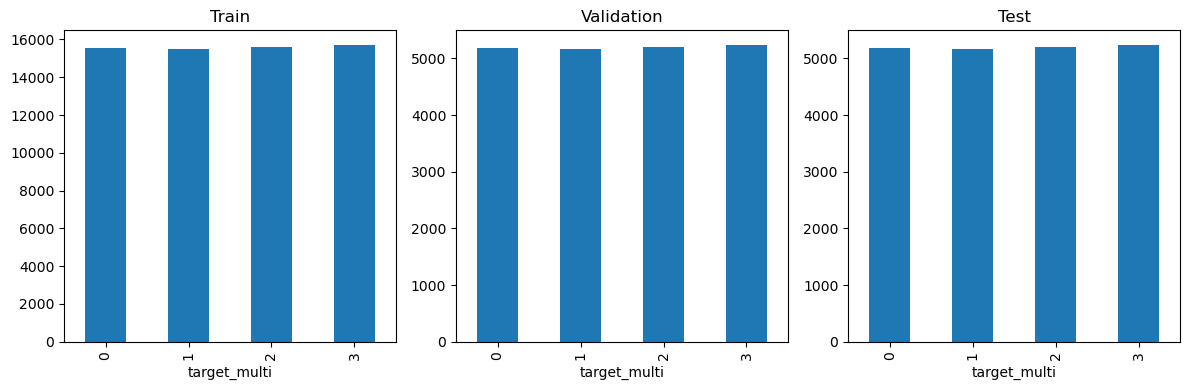

In [ ]:
import pandas as pd

# For the training set
print("Training set class distribution:")
print(y_train.value_counts().sort_index())
print(f"Percentages:\n{y_train.value_counts(normalize=True).sort_index().mul(100).round(2)}")

# For validation set
print("\nValidation set class distribution:")
print(y_val.value_counts().sort_index())

# For test set
print("\nTest set class distribution:")
print(y_test.value_counts().sort_index())

# Visualize
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Train')
y_val.value_counts().sort_index().plot(kind='bar', ax=axes[1], title='Validation')
y_test.value_counts().sort_index().plot(kind='bar', ax=axes[2], title='Test')
plt.tight_layout()
plt.show()

our dataset for the target column is balanced , Also we try different models and methods for multiclassing but Test Accuracy: 0.4613 shows us the features of in the dataset is not appropriate and enough for specting the distance.



## 1. Bias‑variance trade‑off
- Bias: wrong assumptions → underfitting.  
- Variance: sensitive to data changes → overfitting.  
- More complex model → lower bias, higher variance.  
- Our linear models (87% acc) had higher bias, low variance. Random Forest (96% acc) lowered bias but increased variance (train 100% vs val 96%).

## 2. When kernel regression beats linear
- When the true pattern is non‑linear (curved, threshold effects).  
- Passenger satisfaction likely non‑linear (e.g., delay >30 min triggers drop). Kernel RBF could help but Random Forest already did it faster.

## 3. L1 vs L2
- L1 (LASSO): sum of absolute weights → sparse coefficients (some zero), does feature selection.  
- L2 (Ridge): sum of squared weights → shrinks but rarely zero, good for correlated features.  
- LASSO better when many irrelevant features. Ridge better when all features matter or are correlated.  
- L1 gives sparsity because its constraint is diamond‑shaped; optimum often on a corner.

## 4. Why MAPE is unreliable
- Mean Absolute Percentage Error fails when actual values are near zero (division by zero).  
- Also asymmetric.  
- For delay prediction, delays can be 0 → MAPE undefined. Use MAE or RMSE.

## 5. Effect of outliers
- Outliers pull regression line, inflate coefficients.  
- Linear models are sensitive; tree models isolate outliers in leaves.  
- Our departure delay outliers caused coefficient 37 in linear regression; Random Forest handled them better.

## 6. Class imbalance and accuracy
- If 95% satisfied, predicting “satisfied” always gives 95% accuracy but fails on dissatisfied.  
- Better metrics: precision, recall, F1, AUC.  
- Our data was balanced (~50%), so accuracy was fine, but still monitor AUC and F1.

## 7. Decision boundaries of different models
- Linear SVM / Logistic Regression: straight line/plane.  
- Kernel SVM: curved boundaries.  
- Decision Tree: axis‑aligned rectangles.  
- Random Forest: many rectangles averaged → smooth complex boundaries.  
- k‑NN: Voronoi diagram (local majority).  
- Random Forest gave 0.99 AUC due to flexible boundaries.

## 8. Effect of K in KNN
- Small K: low bias, high variance (overfitting).  
- Large K: high bias, low variance (smooth).  
- For our 80k samples, optimal K likely between 10–30.

## 9. Overfitting in decision trees
- Trees can split until pure, memorizing noise.  
- Max depth alone not enough – they can still make many narrow splits.  
- Pruning (cost‑complexity) grows full tree then cuts weak branches using penalty `ccp_alpha`.

## 10. Tree models as feature selectors
- They rank features by importance (Gini, permutation).  
- Features that never split are irrelevant.  
- Our top drivers likely: Departure Delay, Inflight entertainment, On‑board service.

## 11. Micro vs Macro vs Weighted F1
- Micro: aggregate counts → favors large classes.  
- Macro: average per‑class F1 → treats all classes equally, good when minority class matters.  
- Weighted: average weighted by class support → can hide poor small‑class performance.  
- Micro F1 favors large classes because they dominate the counts.

## 12. Multi‑label vs Multiclass
- Multiclass: one of K classes (e.g., Short, Long).  
- Multi‑label: subset of K labels (e.g., [delayed, crowded]).  
- Loss: cross‑entropy (multiclass) vs binary cross‑entropy per label.  
- Thresholding: softmax → argmax vs sigmoid → threshold (0.5).  
- KNN and Decision Trees can be extended: KNN counts labels among neighbors; trees use multi‑label impurity.

## 13. Precision‑recall trade‑off
- Higher precision → lower recall, and vice versa.  
- Controlled by classification threshold.  
- For satisfaction, we might prefer recall (catch dissatisfied passengers) depending on business cost.

## 14. ROC vs PR curve
- ROC (TPR vs FPR): good for balanced classes, optimistic for imbalanced.  
- PR curve (Precision vs Recall): better for imbalanced data, focuses on positive class.  
- Our data balanced → ROC AUC 0.99 is fine.

## 15. Improvements with unlimited resources
- Preprocessing: winsorize outliers, create interactions (delay × distance), target encoding.  
- Features: weather, day of week, holidays, airport congestion.  
- Models: stacking, Bayesian tuning, kernel ensembles, neural networks.  
- Metrics: cost‑sensitive loss, Brier score, Quadratic Weighted Kappa.